In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd /Users/armandoroqueestrada/Proyecto_Proca/stability

/Users/armandoroqueestrada/Proyecto_Proca/Stability


In [3]:
import Modules.Background as bg
import numpy as np

import matplotlib.pyplot as plt
import Modules.Plot as cplot

In [4]:
cplot.general()

### Type of polarizations:

$i)$ $\gamma=0$, $\alpha=0$ if the polarization is linear, 

$ii)$ $\gamma=0$, $\alpha=1$ if the polarization is circular, and 

$iii)$ $\gamma=1$, $\alpha=0$ if the polarization is radial.


### Background solutions

Since we have scaling freedom, we only need to compute $\sigma_0 = 1$ and derive the rest from this.

\begin{align}
t \to \lambda_*^{-1} t, \quad \vec{x}\to \lambda_*^{-1/2} \vec{x},\quad U\to \lambda_x U, \quad \vec\psi \to \lambda_* \vec\psi
\end{align}

In [5]:
s0val = [1, 3]

Finding a profile with nodes: [1]
Final precision: U0 = [2.06157859] radius 22.44734124025077


/Users/armandoroqueestrada/Proyecto_Proca/Stability/Modules/Plot/plot_conf.py:345: UserWarning: The py, pz ccomponents was off because the number of fields is 1
  warnings.warn("The py, pz ccomponents was off because the number of fields is %d"%numFields)


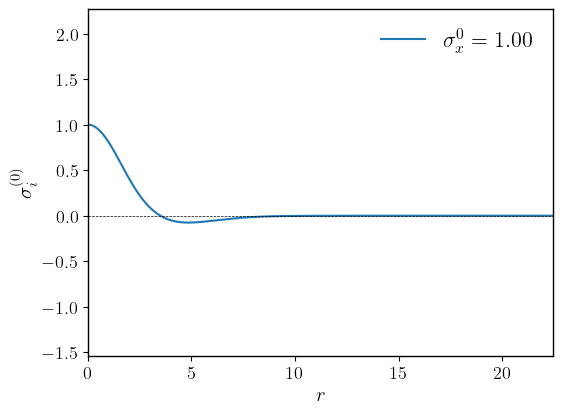

Finding a profile with nodes: [1]
Final precision: U0 = [4.28825628] radius 15.942506669201828


/Users/armandoroqueestrada/Proyecto_Proca/Stability/Modules/Plot/plot_conf.py:345: UserWarning: The py, pz ccomponents was off because the number of fields is 1
  warnings.warn("The py, pz ccomponents was off because the number of fields is %d"%numFields)


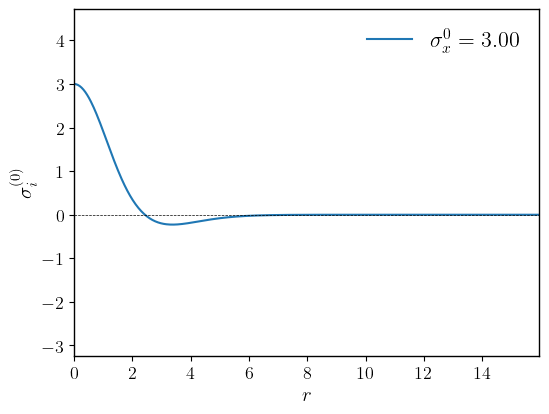

In [6]:
# EXAMPLE: Proca stars radially polarized Proca stars

LambT = 0 # autointeracción: 1 (repulsive), 0 (without selinteraction), -1 (attractive)

nx = 1  # node numbers: nx -> nodes of \sigma_x, ny  -> nodes of \sigma_y, ...
nodos = [nx]  # list of node info

p1x = 0  # The central amplitude of \sigma_x (p0x) and its first derivative value (p1x), the latter is zero
u1x = 0 # The first derivatives of the x.

Ini0 = [None, p1x, u1x]  # boundary conditions list
rmax = 50  # iteration radius

# Range of values used as seed for the effective potential
Uxint = [0.12057279119421096, 18]

met = 'DOP853'
gamma = 1  # gamma = 1 for radially polarized Proca stars

# IMPORTANT: the number of fields must be equal to the number of effective potential components
datos = []
for p0x in s0val:
    Ini0[0] = p0x
    Uintrs = [Uxint]
               
    numFields = len(Uintrs)
    Rtol = 1e-13 
    Atol = 1e-15

    u0Val, rTmax, events = bg.MultFreq_solveG2(Ini0, numFields=numFields, Uintrs=Uintrs, rmax=rmax, LambT=LambT, gamma=gamma, met=met,
                                                nodos=nodos, lim=1e-14, info=False, klim=5000, outval=0, delta=0., Rtol=Rtol, Atol=Atol)

    # plot the result
    U0 = np.zeros(4*numFields)
    U0[:2*numFields] = Ini0[:2*numFields]
    U0[2*numFields+1::2] = Ini0[2*numFields:]
    U0[2*numFields::2] = u0Val
    arg = [numFields, LambT, gamma]

    cplot.plotPerf(U0, rTmax, arg=arg)

    # f0, rmax, gamma, LambT, nodes, posNodes, met, Rtol, Atol, u0
    datos.append([U0[0], rTmax, gamma, LambT, nodos[0], None, met, Rtol, Atol, U0[2]])

Mass values: [15.38477578298805]
Eigenvalues of energy: [-2.082480330943568]


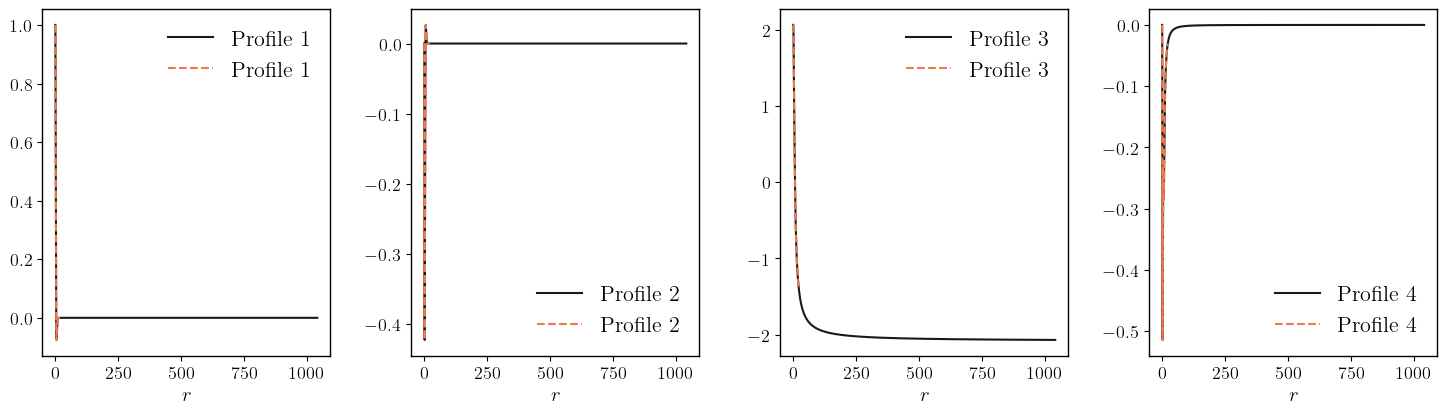

Mass values: [22.188686224224206]
Eigenvalues of energy: [-4.331733656635096]


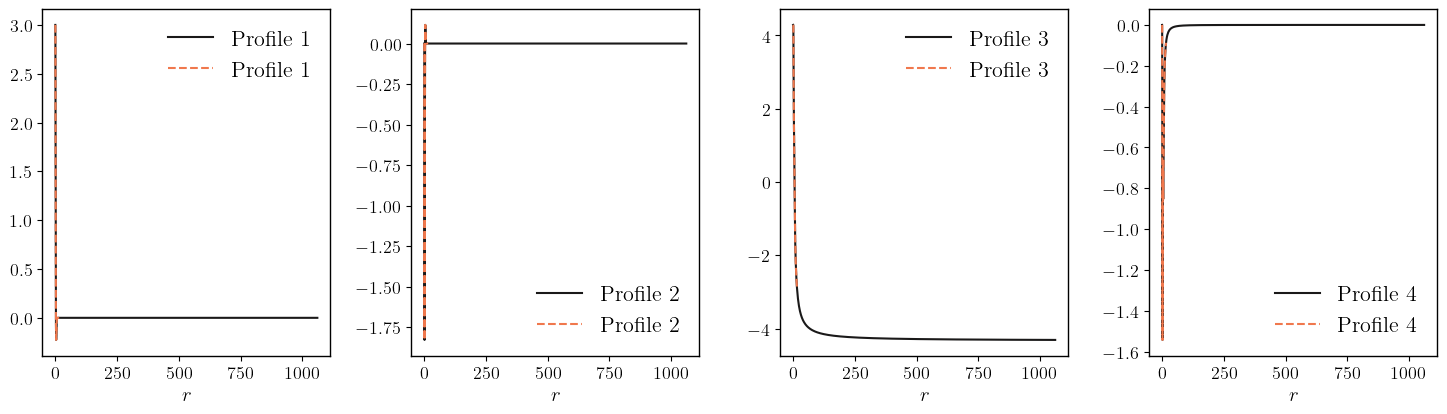

In [7]:
# Extendiendo los perfiles
Ext = 1000 #7000
Np = 1000 #int(2e06)

confidataEx = []
for confi in datos: # confidata datos
    dataEx = bg.mainExt(confi, mult=False, rmin=0, Nptos=Np, met='DOP853', metExp=1, info=True,
                    Rtol=1e-13, Atol=1e-15, deltaExt=Ext, yscale='linear', xscale='linear')  # out [[Ei, rDnew, sDnew, dsDnew, uDnew, duDnew], ..]
    confidataEx.append(dataEx[0])


(0.0, 35.0)

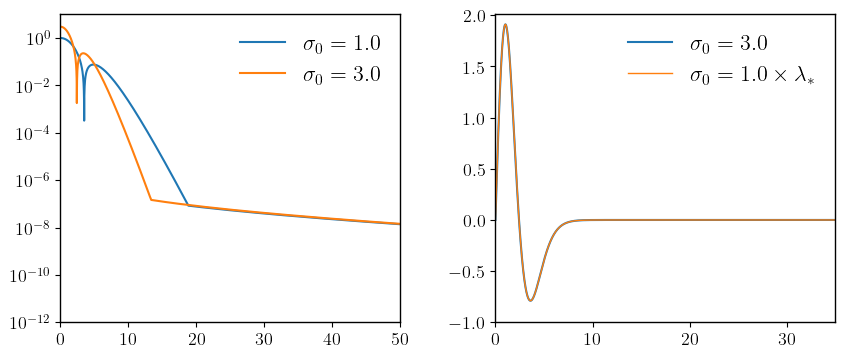

In [8]:
# Test scaling
# [[Ei, rDnew, sDnew, dsDnew, uDnew, duDnew], ..]
Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = confidataEx[0]
Ei1, rDnew1, sDnew1, dsDnew1, uDnew1, duDnew1 = confidataEx[1]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.0, wspace=.28))

ax[0].plot(rDnew, np.abs(sDnew), label=r'$\sigma_0=%2.1f$'%np.abs(sDnew)[0])
ax[0].plot(rDnew1, np.abs(sDnew1), label=r'$\sigma_0=%2.1f$'%np.abs(sDnew1)[0])
ax[0].legend(frameon=False)
ax[0].set_xlim(0, 50)
ax[0].set_yscale('log')
ax[0].set_ylim(1e-12, 10)

###########
ax[1].plot(rDnew1, rDnew1*sDnew1, label=r'$\sigma_0=%2.1f$'%np.abs(sDnew1)[0])

valmax = np.max(rDnew*sDnew)
valmax1 = np.max(rDnew1*sDnew1)
lambdaSt = valmax1/valmax

ax[1].plot(rDnew/np.sqrt(lambdaSt), (rDnew*sDnew)*lambdaSt, lw=1, label=r'$\sigma_0=%2.1f \times \lambda_*$'%np.abs(sDnew)[0])


ax[1].vlines(x=datos[0][3], ymin=1e-9, ymax=1, color='r', lw=0.5, ls='--')
ax[1].vlines(x=datos[1][3]*np.sqrt(lambdaSt), ymin=1e-9, ymax=1, color='k', lw=0.5, ls='-')

#ax[0].set_yscale('log')
#ax[1].set_yscale('log')
ax[1].set_ylim(-1., 2.01)
ax[1].legend(frameon=False)
ax[1].set_xlim(0, 35)

In [9]:
print("lambda_* = ", lambdaSt)

lambda_* =  2.08002577660993


Testeando los autovalores

In [10]:
import Modules.SpectralMeth as sp
from scipy.interpolate import interp1d

In [11]:
s0val

[1, 3]

### $\sigma_0=1$

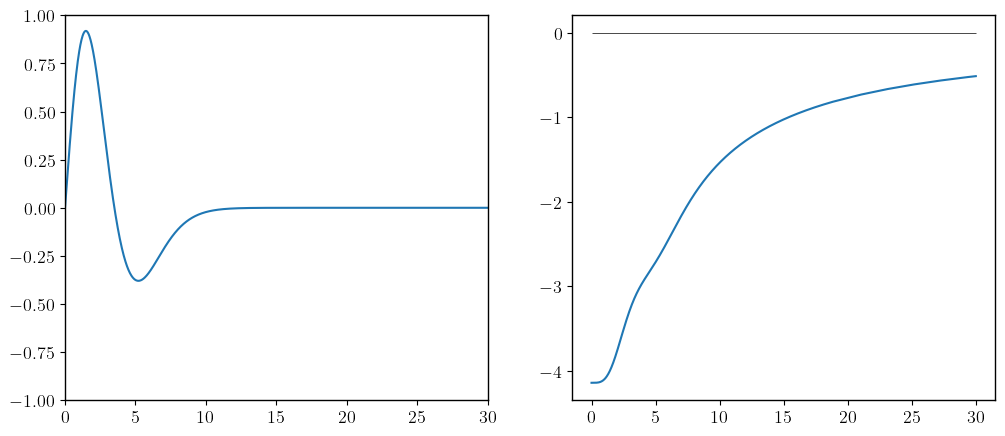

In [12]:
Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = confidataEx[0]

polariz = 'radial'
datFunc = [
    [interp1d(rDnew, rDnew * sDnew)],
    [interp1d(rDnew, uDnew)],
]

nodos = 1
rMax = 30 # 200*(nodos+1) + 150
Nptos = 500 # int(3*rMax/4) * 2

Jval = [0, 1] #, 2, 3]
lamV_list = [[0., 1.], [0., -1.]]   # ln, ls
alp = 0.0

# Graphing
rad2 = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

ax[0].plot(rad2, datFunc[0][0](rad2))
ax[1].plot(rad2, Ei - datFunc[1][0](rad2))
ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_ylim(-1, 1)
# ax[0].set_yscale('log')
plt.show()

lambdaVal_s1, dataExtra_s1 = [], []
for i in range(2):
    lamV = lamV_list[i]
    lambdaVal, dataExtra = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)
    lambdaVal_s1.append(lambdaVal)
    dataExtra_s1.append(dataExtra)


In [14]:
real_eigVal_s1LsP_list = []
for i in range(2):
    real_eigVal_s1LsP = []
    for ind, [Jval, data] in enumerate(dataExtra_s1[i]):
        rdis, eingVal, eigVect = data
        print('Jval = %d'%Jval)
        ind = np.abs(np.real(eingVal)) >= 1e-08 # filtrando los autovalores reales
        print(eingVal[ind])
        real_eigVal_s1LsP.append([Jval, eingVal[ind]])
    print('#'*50)
    real_eigVal_s1LsP_list.append([lamV_list[i], real_eigVal_s1LsP])


Jval = 0
[ 0.00357042-7.13551985e-14j -0.00357042-1.09484766e-13j
  0.3161956 +4.83174025e-13j -0.3161956 +4.83259516e-13j
 -0.3161956 -8.65389565e-14j  0.3161956 -8.66027749e-14j
  0.16288606-8.78432184e-01j -0.16288606-8.78432184e-01j
 -0.16288606+8.78432184e-01j  0.16288606+8.78432184e-01j]
Jval = 1
[-0.03335536+0.28117418j  0.03335536+0.28117418j -0.03335536-0.28117418j
  0.03335536-0.28117418j]
##################################################
Jval = 0
[ 0.00357042-7.13551985e-14j -0.00357042-1.09484766e-13j
  0.16288606-8.78432184e-01j -0.16288606-8.78432184e-01j
 -0.16288606+8.78432184e-01j  0.16288606+8.78432184e-01j]
Jval = 1
[-0.0010231 +3.70539775e-14j  0.0010231 +3.68081995e-14j
  0.10416983-8.39624335e-01j -0.10416983-8.39624335e-01j
  0.10416983+8.39624335e-01j -0.10416983+8.39624335e-01j
  0.12027958+1.56774418e+00j -0.12027958+1.56774418e+00j
  0.12027958-1.56774418e+00j -0.12027958-1.56774418e+00j]
##################################################


Text(0.5, 1.0, '$\\lambda=[0, -1]$')

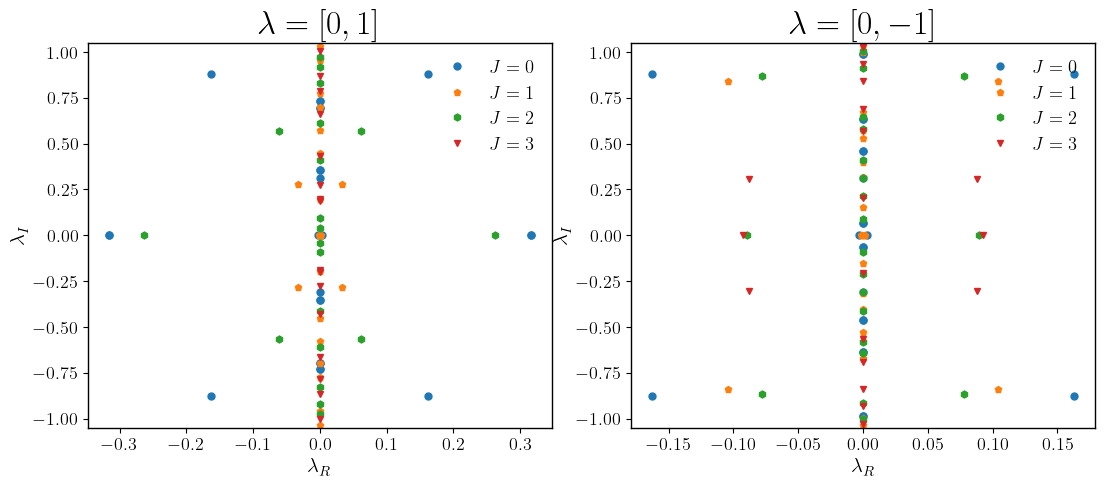

In [23]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5']
mark = ['o', 'p', 'h', 'v']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(13, 5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtra_s1[0]):
    _, eingVal, _ = data
    ax[0].plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)


for ind, [Jval, data] in enumerate(dataExtra_s1[1]):
    _, eingVal, _ = data
    ax[1].plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
for axes in ax:
    axes.legend(frameon=False, fontsize='small')
    #axes.set_xlim(-0.0015, 0.0015)
    axes.set_ylim(-1.05, 1.05)
    axes.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
    axes.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

ax[0].set_title(r'$\lambda=[%1d, %1d]$'%(*lamV_list[0],))
ax[1].set_title(r'$\lambda=[%1d, %1d]$'%(*lamV_list[1],))


### $\sigma_0=3$

30 500


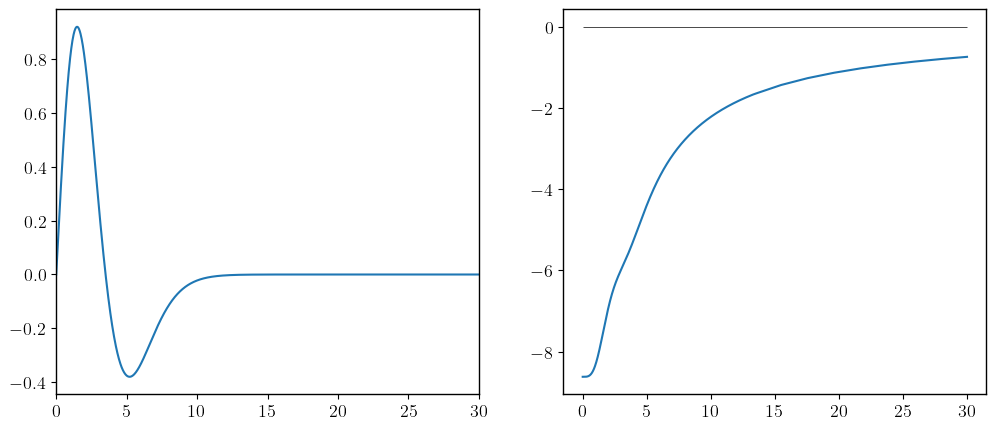

In [15]:
Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = confidataEx[1]

polariz = 'radial'
datFunc = [
    [interp1d(rDnew, rDnew * sDnew)],
    [interp1d(rDnew, uDnew)],
]

#nodos = 1
#rMax = 200*(nodos+1) + 50
#Nptos = int(3*rMax/4) * 2

nodos = 1
rMax = 30 #200*(nodos+1) - 300
Nptos = 500 #int(3*rMax/4) * 4

print(rMax, Nptos)

Jval = [0, 1] #, 1, 2, 3]
lamV_list = [[0., 1.], [0., -1.]]   # ln, ls
alp = 0.0

# Graphing
rad2 = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

ax[0].plot(rad2*np.sqrt(lambdaSt), datFunc[0][0](rad2)/lambdaSt)
ax[1].plot(rad2, Ei - datFunc[1][0](rad2))
ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
# ax[0].set_yscale('log')
plt.show()

lambdaVal_s3, dataExtra_s3 = [], []
for i in range(2):
    lamV = lamV_list[i]
    #lambdaVal, dataExtra = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
    #        Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)
    lambdaVal_s3.append(lambdaVal)
    dataExtra_s3.append(dataExtra)

In [49]:
real_eigVal_s3LsP_list = []
for i in range(2):
    real_eigVal_s3LsP = []
    for ind, [Jval, data] in enumerate(dataExtra_s3[i]):
        rdis, eingVal, eigVect = data
        print('Jval = %d'%Jval)
        ind = np.abs(np.real(eingVal)) >= 1e-08 # filtrando los autovalores reales
        print(eingVal[ind])
        real_eigVal_s3LsP.append([Jval, eingVal[ind]])
    print('#'*50)
    real_eigVal_s3LsP_list.append([lamV_list[i], real_eigVal_s3LsP])

Jval = 0
[ 0.00757643+1.76957651e-12j -0.00757643+1.78489628e-12j
  0.15158797+7.38152960e-01j -0.15158797+7.38152960e-01j
  0.15158797+7.38152960e-01j -0.15158797+7.38152960e-01j
 -0.15158797-7.38152960e-01j  0.15158797-7.38152960e-01j
  0.15158797-7.38152960e-01j -0.15158797-7.38152960e-01j
  0.33881506+1.82721317e+00j -0.33881506+1.82721317e+00j
  0.33881506-1.82721317e+00j -0.33881506-1.82721317e+00j
  2.06106605+2.90050593e-12j -2.06106605+2.90692662e-12j
  2.06106605+7.16333213e-12j -2.06106605+7.16440423e-12j]
##################################################
Jval = 0
[ 0.00757643+1.76957651e-12j -0.00757643+1.78489628e-12j
  0.97710305+2.76136834e-12j -0.97710305+2.76122963e-12j
  0.97710305+2.26520657e-12j -0.97710305+2.26526693e-12j
  0.02074095+1.05485800e+00j -0.02074095+1.05485800e+00j
 -0.02074095-1.05485800e+00j  0.02074095-1.05485800e+00j
  0.02074095-1.05485800e+00j -0.02074095-1.05485800e+00j
 -0.02074095+1.05485800e+00j  0.02074095+1.05485800e+00j
  0.33881506+1.827

In [40]:
np.array([0.00343572-3.39134999e-12j, 0.31621243+5.46642486e-15j, 0.16288952-8.78433940e-01j])

np.array([0.0074545 -2.67069755e-14j, 0.15158642+7.38152564e-01j, 0.33881338-1.82721491e+00j, 2.06106029+1.07121953e-13j])/lambdaSt

array([0.00358385-1.28397329e-14j, 0.07287718+3.54876643e-01j,
       0.16288903-8.78457820e-01j, 0.99088209+5.15003007e-14j])

In [ ]:
Jval = 0
[ 0.00343572-3.39134999e-12j -0.00343572+3.74859905e-12j
  0.16288729-8.78433107e-01j -0.16288729-8.78433107e-01j
  0.16288729+8.78433107e-01j -0.16288729+8.78433107e-01j]

In [ ]:
[-0.00358502-8.86765155e-13j  0.00358502-8.54521075e-13j
  0.31619515+2.28657234e-12j -0.31619515+2.28650068e-12j
 -0.31619515-3.23423088e-12j  0.31619515-3.23443766e-12j
 -0.16288562-8.78432316e-01j  0.16288562-8.78432316e-01j
 -0.16288562+8.78432316e-01j  0.16288562+8.78432316e-01j]

Text(0.5, 1.0, '$\\lambda=[0, -1]$')

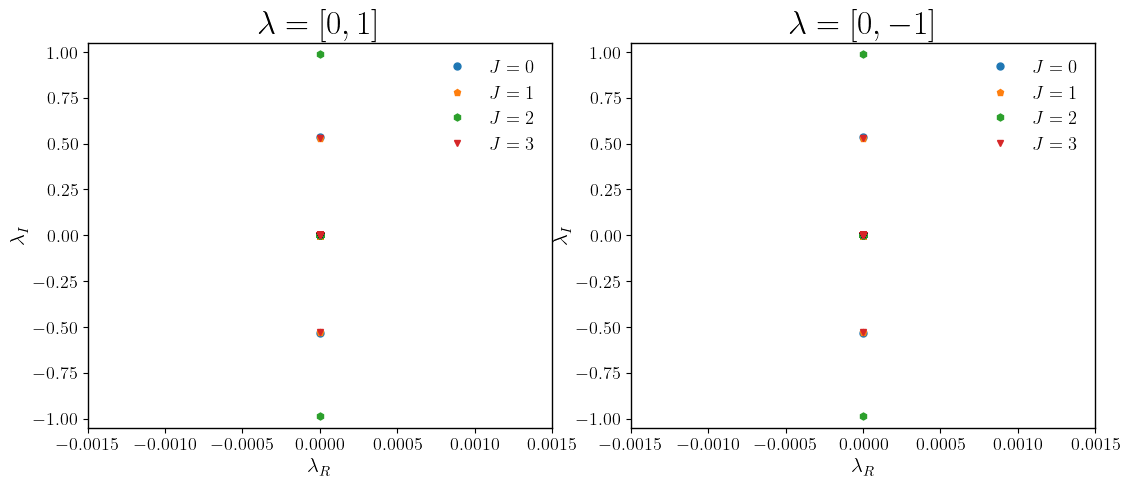

In [35]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5']
mark = ['o', 'p', 'h', 'v']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(13, 5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtra_s3[0]):
    _, eingVal, _ = data
    ax[0].plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)


for ind, [Jval, data] in enumerate(dataExtra_s3[1]):
    _, eingVal, _ = data
    ax[1].plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
for axes in ax:
    axes.legend(frameon=False, fontsize='small')
    axes.set_xlim(-0.0015, 0.0015)
    axes.set_ylim(-1.05, 1.05)
    axes.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
    axes.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

ax[0].set_title(r'$\lambda=[%1d, %1d]$'%(*lamV_list[0],))
ax[1].set_title(r'$\lambda=[%1d, %1d]$'%(*lamV_list[1],))

### Comparando

In [49]:
[Jval_s1, eingVal_s1] = real_eigVal_s1LsP_list[0][1][1]
[Jval_s3, eingVal_s3] = real_eigVal_s3LsP_list[0][1][1]

eingVal_s1 * lambdaSt - eingVal_s3

array([ 0.01282931-8.60442041e-13j, -0.01282931+9.39297384e-13j])

In [52]:
real_eigVal_s1LsP_list[0][1][1], real_eigVal_s3LsP_list[0][1][1]

([1, array([ 0.00226285-1.13913600e-15j, -0.00226285+6.68858753e-14j])],
 [1, array([-0.00604075+8.57024633e-13j,  0.00604075-7.38639758e-13j])])

0 [-6.36644652e-03-2.07504082e-12j  6.36644652e-03-1.85036280e-12j
 -4.43823071e-06-3.49744571e+00j  4.43823071e-06-3.49744571e+00j
 -4.43822892e-06+3.49744571e+00j  4.43822892e-06+3.49744571e+00j]
1 [ 0.01282931-8.60442041e-13j -0.01282931+9.39297384e-13j]
2 [ 4.76722662e-07-3.45669411e-14j -4.76722662e-07-3.82697346e-14j]
3 []
0 [-6.36644652e-03-2.07504082e-12j  6.36644652e-03-1.85036280e-12j
 -4.43823071e-06-3.49744571e+00j  4.43823071e-06-3.49744571e+00j
 -4.43822892e-06+3.49744571e+00j  4.43822892e-06+3.49744571e+00j]
1 [ 0.01282931-8.60442041e-13j -0.01282931+9.39297384e-13j]
2 [ 4.76722662e-07-3.45669411e-14j -4.76722662e-07-3.82697346e-14j]
3 []


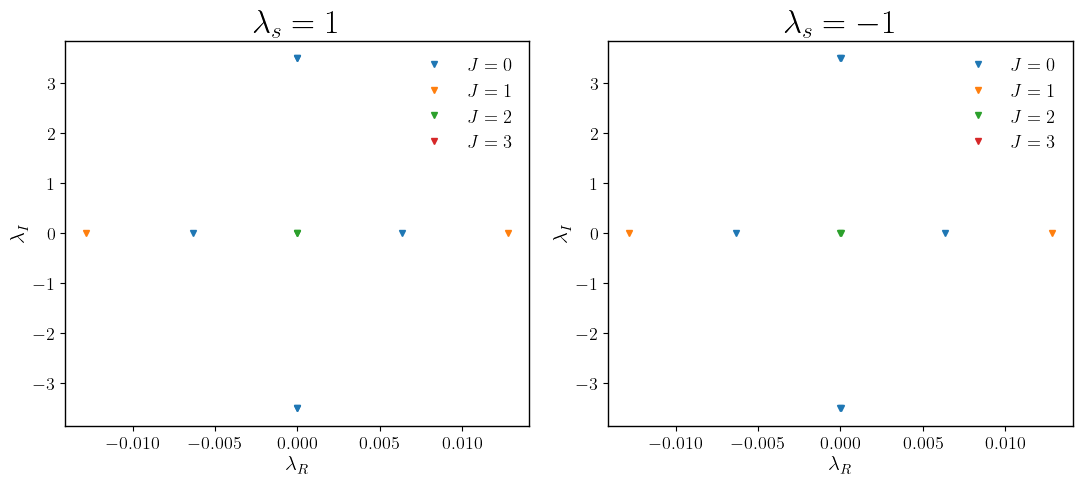

In [60]:

col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5']
mark = ['o', 'p', 'h', 'v']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(13, 5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )

for Jind in range(len(real_eigVal_s1LsP_list[0][1])):
    [Jval_s1, eingVal_s1] = real_eigVal_s1LsP_list[0][1][Jind]
    [Jval_s3, eingVal_s3] = real_eigVal_s3LsP_list[0][1][Jind]

    print(Jind, eingVal_s1 * lambdaSt - eingVal_s3)

    ax[0].plot(np.real(eingVal_s1 * lambdaSt - eingVal_s3), np.imag(eingVal_s1 * lambdaSt - eingVal_s3), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval_s1)


for Jind in range(len(real_eigVal_s1LsP_list[1][1])):
    [Jval_s1, eingVal_s1] = real_eigVal_s1LsP_list[1][1][Jind]
    [Jval_s3, eingVal_s3] = real_eigVal_s3LsP_list[1][1][Jind]

    print(Jind, eingVal_s1 * lambdaSt - eingVal_s3)

    ax[1].plot(np.real(eingVal_s1 * lambdaSt - eingVal_s3), np.imag(eingVal_s1 * lambdaSt - eingVal_s3), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval_s1)

ax[0].set_title(r'$\lambda_s=1$')
ax[1].set_title(r'$\lambda_s=-1$')

for axes in ax:
    axes.legend(frameon=False, fontsize='small')
    axes.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
    axes.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]